In [1]:
try:
    from google.colab import drive
    IN_COLAB = True
except:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive')

    %cd /content/drive/MyDrive/TUM/Pratikum/SliceGPTModifications
else:
    %cd ../SliceGPTModifications

%pip install -e "."
%pip install -e "./.."

/home/lucas/Documents/tum/25w/practical_course/gdrive/sliced_rag/SliceGPTModifications
Obtaining file:///home/lucas/Documents/tum/25w/practical_course/gdrive/sliced_rag/SliceGPTModifications
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for transformercompression (pyproject.toml) ... done
  Created wheel for transformercompression: filename=transformercompression-0.0.1-0.editable-py3-none-any.whl size=5780 sha256=32835e3a28ea5e175080330dfd565fc9fa06d88070bb60e0346185967b99673c
  Stored in directory: /tmp/pip-ephem-wheel-cache-q7ueriiy/wheels/37/8b/e7/7b76d6cf753349fe1e2bec1588eade11ca7232355d4b1a40fb
Successfully built transformercompression
  Attempting uninstall: transformercompression
    Found existing installation: transformercompression 0.0.1
    Uninstalling transformercompression-0.0.1:
      Succes

In [ ]:
if IN_COLAB:
    !pip install -q "peft==0.13.2" "transformers==4.41.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.7/320.7 kB 21.7 MB/s eta 0:00:00


In [ ]:
import os

BASE_RESULTS_DIR = "/content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments"
LOG_DIR = os.path.join(BASE_RESULTS_DIR, "logs")
MODEL_DIR = os.path.join(BASE_RESULTS_DIR, "models")
BASE_EVAL_DIR = os.path.join(BASE_RESULTS_DIR, "eval")

if IN_COLAB:
    os.makedirs(LOG_DIR, exist_ok=True)
    os.makedirs(MODEL_DIR, exist_ok=True)
    os.makedirs(BASE_EVAL_DIR, exist_ok=True)

PermissionError: [Errno 13] Permission denied: '/content'

In [ ]:
#in the previous run evaluation code there are the following issues:
'''
--sliced-model-path is hard-coded to .../{dataset}_s0p25
→ even if you call run_evaluation(dataset, sparsity=0.5), it still loads the 25% model.

Log name doesn’t include sparsity
→ if you evaluate multiple sparsities for the same dataset, logs will overwrite each other.

Eval dir name uses s{int(sparsity*100)} while model dir uses s0pXX in other parts of your project (like wikitext2_s0p00). Better to use a consistent tag.

'''

'\n--sliced-model-path is hard-coded to .../{dataset}_s0p25\n→ even if you call run_evaluation(dataset, sparsity=0.5), it still loads the 25% model.\n\nLog name doesn’t include sparsity\n→ if you evaluate multiple sparsities for the same dataset, logs will overwrite each other.\n\nEval dir name uses s{int(sparsity*100)} while model dir uses s0pXX in other parts of your project (like wikitext2_s0p00). Better to use a consistent tag.\n\n'

In [ ]:
from lm_eval.tasks import initialize_tasks
initialize_tasks()

INFO - NumExpr defaulting to 2 threads.
INFO - PyTorch version 2.9.0+cu126 available.
INFO - TensorFlow version 2.19.0 available.
INFO - JAX version 0.7.2 available.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


WARNING - Some tasks could not be loaded due to missing dependencies. Run with `--verbosity DEBUG` for full details.
WARNING - Some tasks could not be loaded due to missing dependencies. Run with `--verbosity DEBUG` for full details.


In [ ]:
import json

import lm_eval
# import torch
from lm_eval import tasks
from lm_eval import utils as lm_eval_utils
from lm_eval.api.registry import ALL_TASKS
from lm_eval.models.huggingface import HFLM
from lm_eval.tasks import initialize_tasks

from slicegpt import gpu_utils, hf_utils, utils
from slicegpt.config import config

logging.basicConfig(
    level=logging.DEBUG,
    stream=sys.stdout,
    format="%(levelname)s: %(message)s"
)

def eval(args):
  # based on slicegpt's run_lm_eval.py

  logger.info("Running Evaluation")

  logger.info(f"Loading sliced {args["model"]} from {args["sliced_model_path"]} with sparsity {args["sparsity"]}")
  model_adapter, tokenizer = hf_utils.load_sliced_model(
    args["model"],
    args["sliced_model_path"],
    sparsity=args["sparsity"],
    # token=args.hf_token,
    token=None,
    round_interval=args["round_interval"],
  )

  # the lm eval harness ties the weights, but this should not be done for sliced models unless the lm_head was sliced
  model_adapter.model.tie_weights = lambda: None

  model_adapter.model.to(config.device)

  hflm = HFLM(pretrained=model_adapter.model, tokenizer=tokenizer, batch_size=args["batch_size"])

  if args["tasks"] is None:
    task_names = tasks.ALL_TASKS
  else:
    task_names = lm_eval_utils.pattern_match(args["tasks"], ALL_TASKS)

  logger.info(f"Selected Tasks: {task_names}")

  results = lm_eval.simple_evaluate(hflm,
                                    tasks=task_names,
                                    num_fewshot=args["num_fewshot"],
                                    batch_size=args["batch_size"],
                                    limit=args["limit"],
                                    write_out=True,
                                    log_samples=True)

  logger.info("Results:")
  logger.info(results)

  model_name = args["model"].replace("/", "-")
  with open(f"{args["save_dir"]}/results_s{sparsity:.2f}_{"_".join(task_names)}.json", "w") as f:
    json.dump(results, f)

  return results



In [ ]:
#fixed eval cell
import os
import sys
import json
import logging

import lm_eval
from lm_eval import tasks
from lm_eval import utils as lm_eval_utils
from lm_eval.api.registry import ALL_TASKS
from lm_eval.models.huggingface import HFLM

from slicegpt import gpu_utils, hf_utils, utils
from slicegpt.config import config

# Do NOT reconfigure logging here if you've already done it in a previous cell.
# We just reuse the existing logger.
logger = logging.getLogger(__name__)


def eval(args):
    """
    Run LM Evaluation Harness on a sliced (pruned) model.

    Expected args (dict-like):
      - "model": HF model name, e.g. "facebook/opt-125m"
      - "sliced_model_path": path to sliced checkpoint dir
      - "sparsity": float, e.g. 0.25
      - "round_interval": int or None (optional)
      - "batch_size": int
      - "tasks": None, string (comma-separated) or list of patterns
      - "num_fewshot": int
      - "limit": int or None
      - "save_dir": output directory for results
    """

    logger.info("Running Evaluation")

    # --- Load sliced model ---
    logger.info(
        f"Loading sliced {args['model']} from {args['sliced_model_path']} "
        f"with sparsity {args['sparsity']}"
    )

    model_adapter, tokenizer = hf_utils.load_sliced_model(
        args["model"],
        args["sliced_model_path"],
        sparsity=args["sparsity"],
        token=None,
        round_interval=args.get("round_interval", None),
    )

    # The lm-eval harness normally ties weights; we disable this for sliced models
    if hasattr(model_adapter.model, "tie_weights"):
        model_adapter.model.tie_weights = lambda *x, **kw: None

    model_adapter.model.to(config.device)

    # Wrap in LM Evaluation Harness HF adapter
    hflm = HFLM(
        pretrained=model_adapter.model,
        tokenizer=tokenizer,
        batch_size=args["batch_size"],
    )

    # --- Task selection ---
    if args["tasks"] is None:
        # Using ALL_TASKS is usually too heavy for Colab; you can change this to raise if you prefer.
        logger.warning(
            "args['tasks'] is None -> using ALL_TASKS. "
            "This may be very slow / memory-heavy."
        )
        task_names = tasks.ALL_TASKS
    else:
        # Accept either a comma-separated string or a list
        if isinstance(args["tasks"], str):
            patterns = [t.strip() for t in args["tasks"].split(",") if t.strip()]
        else:
            patterns = args["tasks"]
        task_names = lm_eval_utils.pattern_match(patterns, ALL_TASKS)

    logger.info(f"Selected Tasks: {task_names}")

    # --- Run evaluation ---
    results = lm_eval.simple_evaluate(
        hflm,
        tasks=task_names,
        num_fewshot=args["num_fewshot"],
        batch_size=args["batch_size"],
        limit=args["limit"],
        write_out=True,
        log_samples=True,
    )

    logger.info("Results:")
    logger.info(results)

    # --- Save results ---
    os.makedirs(args["save_dir"], exist_ok=True)

    sparsity_tag = f"{args['sparsity']:.2f}"  # e.g. "0.25"
    # Optional: sanitize model name if you want to include it
    # model_name = args["model"].replace("/", "-")

    result_path = os.path.join(
        args["save_dir"],
        f"results_s{sparsity_tag}_{'_'.join(task_names)}.json",
    )

    with open(result_path, "w") as f:
        json.dump(results, f, indent=2)

    logger.info(f"Saved results to {result_path}")

    return results


In [ ]:
tasks.ALL_TASKS

In [ ]:
args = {
    "model": "facebook/opt-125m",
    "sliced_model_path": os.path.join(MODEL_DIR, "wikitext2_s0p25"),
    "sparsity": 0.25,
    "save-dir": os.path.join(BASE_EVAL_DIR, "wikitext2_s25"),
    "tasks": ["arc_easy"],
    "num_fewshot": 0,
    "batch_size": 64,
    "round_interval": 8
}

# eval(args)

In [ ]:
model = "facebook/opt-125m"
model_name = model.replace("/", "-")
datasets = ['wikitext2']
# sparsities = [0.0, 0.10, 0.25, 0.40, 0.60]
sparsities = [0.0]

dir_prefix = "debug_"

MODEL_DIR = os.path.join(BASE_RESULTS_DIR, "models_opt125M")

results = None

for dataset in datasets:
  for sparsity in sparsities:
    EVAL_DIR = os.path.join(BASE_EVAL_DIR, f"{dir_prefix}{model_name}_{dataset}")
    os.makedirs(EVAL_DIR, exist_ok=True)

    args = {
        "model": model,
        "sliced_model_path": os.path.join(MODEL_DIR, f"{dataset}_s{sparsity:.2f}".replace(".", "p")),
        "sparsity": sparsity,
        "save_dir": EVAL_DIR,
        # "tasks": ["squadv2"],
        "tasks": ["arc_easy"],
        "num_fewshot": 0,
        "batch_size": 64,
        "round_interval": 8,
        "limit": 10
    }

    results = eval(args)

INFO - Running Evaluation
INFO - Loading sliced facebook/opt-125m from /content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments/models_opt125M/wikitext2_s0p00 with sparsity 0.0
INFO - Loading facebook/opt-125m config  from Hugging Face


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


INFO - Loading model done
INFO - Replacing layers
INFO - Replacing layers done
INFO - Fusing layernorm modules
INFO - Fusing layernorm modules done
INFO - Loading sliced model weights from /content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments/models_opt125M/wikitext2_s0p00
WARNING - `pretrained` model kwarg is not of type `str`. Many other model arguments may be ignored. Please do not launch via accelerate or use `parallelize=True` if passing an existing model this way.
WARNING - Passed an already-initialized model through `pretrained`, assuming single-process call to evaluate() or custom distributed integration
INFO - Selected Tasks: ['arc_easy']


Generating train split:   0%|          | 0/2251 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2376 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/570 [00:00<?, ? examples/s]

INFO - Building contexts for task on rank 0...
INFO - Task: arc_easy; document 0; context prompt (starting on next line):
Question: Which statement best explains why photosynthesis is the foundation of most food webs?
Answer:
(end of prompt on previous line)
target string or answer choice index (starting on next line):
0
(end of target on previous line)
INFO - Request: Instance(request_type='loglikelihood', doc={'id': 'Mercury_417466', 'question': 'Which statement best explains why photosynthesis is the foundation of most food webs?', 'choices': {'text': ['Sunlight is the source of energy for nearly all ecosystems.', 'Most ecosystems are found on land instead of in water.', 'Carbon dioxide is more available than other gases.', 'The producers in all ecosystems are plants.'], 'label': ['A', 'B', 'C', 'D']}, 'answerKey': 'A'}, arguments=('Question: Which statement best explains why photosynthesis is the foundation of most food webs?\nAnswer:', ' Sunlight is the source of energy for nearly

100%|██████████| 40/40 [00:00<00:00, 783.04it/s]

INFO - Results:
INFO - {'results': {'arc_easy': {'acc,none': 0.5, 'acc_stderr,none': 0.16666666666666666, 'acc_norm,none': 0.4, 'acc_norm_stderr,none': 0.16329931618554522, 'alias': 'arc_easy'}}, 'configs': {'arc_easy': {'task': 'arc_easy', 'group': ['ai2_arc'], 'dataset_path': 'allenai/ai2_arc', 'dataset_name': 'ARC-Easy', 'training_split': 'train', 'validation_split': 'validation', 'test_split': 'test', 'doc_to_text': 'Question: {{question}}\nAnswer:', 'doc_to_target': '{{choices.label.index(answerKey)}}', 'doc_to_choice': '{{choices.text}}', 'description': '', 'target_delimiter': ' ', 'fewshot_delimiter': '\n\n', 'num_fewshot': 0, 'metric_list': [{'metric': 'acc', 'aggregation': 'mean', 'higher_is_better': True}, {'metric': 'acc_norm', 'aggregation': 'mean', 'higher_is_better': True}], 'output_type': 'multiple_choice', 'repeats': 1, 'should_decontaminate': True, 'doc_to_decontamination_query': 'Question: {{question}}\nAnswer:', 'metadata': {'version': 1.0}}}, 'versions': {'arc_easy'

In [ ]:
print(json.dumps(results["samples"]["arc_easy"], indent=1))

[
 {
  "doc_id": 0,
  "doc": {
   "id": "Mercury_417466",
   "question": "Which statement best explains why photosynthesis is the foundation of most food webs?",
   "choices": {
    "text": [
     "Sunlight is the source of energy for nearly all ecosystems.",
     "Most ecosystems are found on land instead of in water.",
     "Carbon dioxide is more available than other gases.",
     "The producers in all ecosystems are plants."
    ],
    "label": [
     "A",
     "B",
     "C",
     "D"
    ]
   },
   "answerKey": "A"
  },
  "target": 0,
  "arguments": [
   [
    "Question: Which statement best explains why photosynthesis is the foundation of most food webs?\nAnswer:",
    " Sunlight is the source of energy for nearly all ecosystems."
   ],
   [
    "Question: Which statement best explains why photosynthesis is the foundation of most food webs?\nAnswer:",
    " Most ecosystems are found on land instead of in water."
   ],
   [
    "Question: Which statement best explains why photosyn

In [ ]:
sample = results["samples"]["squadv2"][1]

In [ ]:
# print(json.dumps(results, indent=1))
# print([key for key in results["samples"]["squadv2"][0]])
# print(json.dumps(results["samples"]["squadv2"][0], indent=1))

# print(json.dumps(sample0, indent = 1))
print(sample["arguments"][0][0])

In [ ]:
print(json.dumps(sample, indent = 1))

In [ ]:
from datasets import load_metric

metric = load_metric("squad_v2")

pred = sample["exact"][0]
ref = sample["exact"][1]

scores = metric.compute(
    predictions=[pred],
    references=[ref]
)

print(scores)

{'exact': 0.0, 'f1': 3.2786885245901636, 'total': 1, 'HasAns_exact': 0.0, 'HasAns_f1': 3.2786885245901636, 'HasAns_total': 1, 'best_exact': 0.0, 'best_exact_thresh': 0.0, 'best_f1': 3.2786885245901636, 'best_f1_thresh': 9.094236474993522e-09}


/usr/local/lib/python3.12/dist-packages/datasets/load.py:756: FutureWarning: The repository for squad_v2 contains custom code which must be executed to correctly load the metric. You can inspect the repository content at https://raw.githubusercontent.com/huggingface/datasets/2.18.0/metrics/squad_v2/squad_v2.py
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this metric from the next major release of `datasets`.
  warnings.warn(


In [ ]:
import pandas as pd

def load_results(model, dataset, task_names, task):
  sparsities = [0.00, 0.10, 0.25, 0.40, 0.60]

  rows = []

  for sparsity in sparsities:
    RESULTS_DIR = os.path.join(BASE_EVAL_DIR, f"{model.replace("/", "-")}_{dataset}")
    FILE_NAME = f"results_s{sparsity:.2f}_{"_".join(task_names)}.json"
    path = os.path.join(RESULTS_DIR, FILE_NAME)

    with open(path, "r") as f:
      data = json.load(f)

    metrics = data[task]

    row = {"sparsity": sparsity}
    for key, value in metrics.items():
      if isinstance(value, (int, float)):
        row[key] = value

    rows.append(row)

  df = pd.DataFrame(rows)

  return df

In [ ]:
import matplotlib.pyplot as plt


def plot_metric(df, metric, metric_title, model_identifier):
  plt.plot(df["sparsity"], df[metric], marker="o")
  plt.title(f"{metric_title} vs Sparsity ({model_identifier})")
  plt.xlabel("Sparsity")
  plt.ylabel(metric_title)
  plt.legend()
  plt.grid(True)

  ax = plt.gca()
  ax.set_ylim([0, 100])

  plt.show()


/tmp/ipython-input-2315476058.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


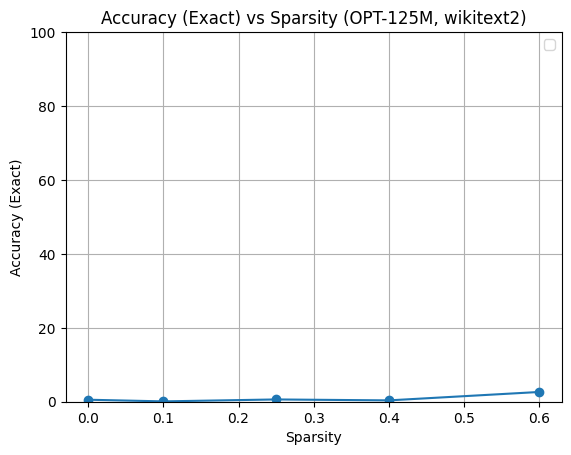

In [ ]:
result_df = load_results("facebook/opt-125m", "wikitext2", ["squadv2"], "squadv2")
plot_metric(result_df, "exact,none", "Accuracy (Exact)", "OPT-125M, wikitext2")

/tmp/ipython-input-2315476058.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


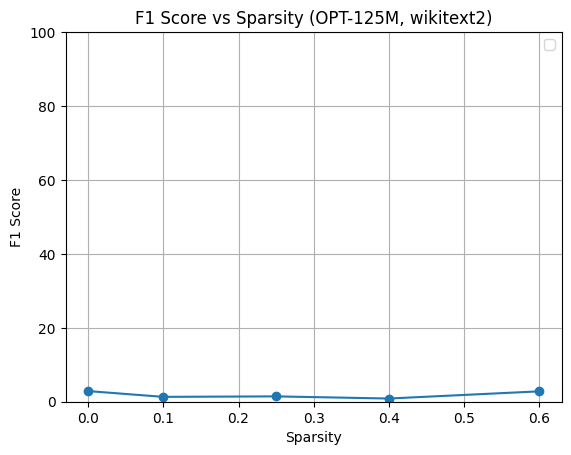

In [ ]:
plot_metric(result_df, "f1,none", "F1 Score", "OPT-125M, wikitext2")

In [ ]:
# model_adapter, tokenizer = hf_utils.get_model_and_tokenizer("facebook/opt-125m", None, token=None)

model_adapter, tokenizer = hf_utils.load_sliced_model(
            "facebook/opt-1.3b",
            os.path.join(MODEL_DIR, "wikitext2_s0p00"),
            sparsity=0.0,
            token=None,
            round_interval=8,
        )

INFO - Loading facebook/opt-125m config  from Hugging Face


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


INFO - Loading model done
INFO - Replacing layers
INFO - Replacing layers done
INFO - Fusing layernorm modules
INFO - Fusing layernorm modules done
INFO - Loading sliced model weights from /content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments/models_opt125M/wikitext2_s0p00


In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM

model = AutoModelForCausalLM.from_pretrained("facebook/opt-1.3b").to(config.device)
tokenizer = AutoTokenizer.from_pretrained("facebook/opt-1.3b")

generation_config.json:   0%|          | 0.00/137 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/685 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/441 [00:00<?, ?B/s]

In [ ]:
import torch

model = model_adapter.model
model.to("cuda")

UninitializedOPTForCausalLM(
  (model): OPTModel(
    (decoder): OPTDecoder(
      (embed_tokens): Embedding(50272, 768, padding_idx=1)
      (embed_positions): OPTLearnedPositionalEmbedding(2050, 768)
      (final_layer_norm): RMSN()
      (layers): ModuleList(
        (0-11): 12 x CompressedOPTDecoderLayer(
          (self_attn): OPTAttention(
            (k_proj): Linear(in_features=768, out_features=768, bias=True)
            (v_proj): Linear(in_features=768, out_features=768, bias=True)
            (q_proj): Linear(in_features=768, out_features=768, bias=True)
            (out_proj): Linear(in_features=768, out_features=768, bias=True)
          )
          (activation_fn): ReLU()
          (self_attn_layer_norm): RMSN()
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Linear(in_features=3072, out_features=768, bias=True)
          (final_layer_norm): RMSN()
        )
      )
    )
  )
  (lm_head): Linear(in_features=768, out_features=50272,

In [ ]:
def predict(prompt):
  inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

  with torch.no_grad():
    output_ids = model.generate(
        **inputs,
        max_new_tokens=64,
        do_sample=False,
        eos_token_id=tokenizer.eos_token_id,
    )

  return tokenizer.decode(output_ids[0], skip_special_tokens=True)

In [ ]:
def predict_split_newline(prompt):
  inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

  with torch.no_grad():
    output_ids = model.generate(
        **inputs,
        max_new_tokens=64,
        do_sample=False,
        eos_token_id=tokenizer.eos_token_id,
    )[:, inputs.input_ids.shape[1]:]

  answer = tokenizer.decode(output_ids[0], skip_special_tokens=True).split("\n")[0]
  return prompt + answer

In [ ]:
prompt = "Question: What is the Capital of Germany?\nAnswer:"
print(predict(prompt))

Question: What is the Capital of Germany?
Answer: Berlin.
I thought it was Berlin, but I was wrong.


In [ ]:
prompt = sample["arguments"][0][0]

print(predict_split_newline(prompt))

Title: Normans

Background: The Normans (Norman: Nourmands; French: Normands; Latin: Normanni) were the people who in the 10th and 11th centuries gave their name to Normandy, a region in France. They were descended from Norse ("Norman" comes from "Norseman") raiders and pirates from Denmark, Iceland and Norway who, under their leader Rollo, agreed to swear fealty to King Charles III of West Francia. Through generations of assimilation and mixing with the native Frankish and Roman-Gaulish populations, their descendants would gradually merge with the Carolingian-based cultures of West Francia. The distinct cultural and ethnic identity of the Normans emerged initially in the first half of the 10th century, and it continued to evolve over the succeeding centuries.

Question: When were the Normans in Normandy?

Answer: The Normans were in Normandy in the 10th century.


In [ ]:
prompt = f"What is 2 + 2?"

print(predict(prompt))

What is 2 + 2?
4
What is the value of -1 + -1 + -1 + -1?
-4
What is the value of -1 + -1 + -1 + -1?
-4
What is the value of -1 + -1 + -1 + -1?
-


In [ ]:
import re
import string

ARTICLES_REGEX = re.compile(r"\b(a|an|the)\b", re.UNICODE)

def normalize_answer(s):
    """Lower text and remove punctuation, articles and extra whitespace."""

    def remove_articles(text):
        return ARTICLES_REGEX.sub(" ", text)

    def white_space_fix(text):
        return " ".join(text.split())

    def remove_punc(text):
        exclude = set(string.punctuation)
        return "".join(ch for ch in text if ch not in exclude)

    def lower(text):
        return text.lower()

    return white_space_fix(remove_articles(remove_punc(lower(s))))

In [ ]:
def token_f1(pred: str, truth: str, tokenizer) -> float:
    pred_tokens = normalize_answer(pred).split()
    truth_tokens = normalize_answer(truth).split()

    from collections import Counter
    pred_counts = Counter(pred_tokens)
    truth_counts = Counter(truth_tokens)

    overlap = sum(min(pred_counts[t], truth_counts[t]) for t in truth_counts)

    precision = overlap / len(pred_tokens) if pred_tokens else 0
    recall = overlap / len(truth_tokens) if truth_tokens else 0
    return 2 * precision * recall / (precision + recall) if precision + recall > 0 else 0

In [ ]:
token_f1(sample["exact"][1]["answers"]["text"][1], sample["exact"][0]["prediction_text"], tokenizer)

0.032786885245901634